# 02 · Strokes Gained and ratings

We want one number per player per shot type, in strokes per round, that we can trust enough to draft with. First we measure each shot against the field, then we separate skill from luck.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import spearmanr

from src.data_prep import load_clean, HOLE_KEY, LIE_LABEL
from src.strokes_gained import Baseline, add_strokes_gained, round_table, CATEGORIES, OWN_CURVE
from src.ratings import fit_ratings, rate_all
from src.validation import evaluate_grid
from src.profiles import style_profile
from src.viz import set_style, PALETTE, NEUTRAL, INK_2

set_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
DIVERGING = LinearSegmentedColormap.from_list("div", [PALETTE[1], "#f0efec", PALETTE[0]])

## Expected strokes from any spot

How many strokes does the field need to hole out from a given lie and distance? We average it from the data, and force it never to fall as distance grows (isotonic regression).

In [2]:
shots, course_holes = load_clean("../data/shot_data.csv")
fit_rows = shots[~shots.low_quality_event & ~shots.score_only_hole & shots.lie_before.notna() & ~shots.is_penalty]
base = Baseline.fit(fit_rows)
print(f"Baseline fitted on {len(fit_rows):,} strokes")

tbl = base.table()
tbl.index = [f"{i} · {LIE_LABEL.get(i, 'pooled trouble lies')}" for i in tbl.index]
tbl.round(2)

Baseline fitted on 626,797 strokes


,1,3,5,10,20,30,50,75,100,125,150,175,200,250,300,400,500
LIE_10 · Rough (light / first cut),1.94,1.94,1.96,2.16,2.38,2.55,2.68,2.75,2.81,2.91,3.01,3.12,3.30,3.58,3.78,3.82,3.82
LIE_11 · Bunker,2.56,2.56,2.56,2.56,2.71,2.86,3.01,3.08,3.18,3.25,3.34,3.48,3.62,3.86,4.09,4.33,4.33
LIE_15 · Rough,2.16,2.16,2.16,2.28,2.49,2.64,2.81,2.87,2.95,3.05,3.17,3.28,3.41,3.69,3.90,3.97,3.97
LIE_16 · Tee,2.97,2.97,2.97,2.97,2.97,2.97,2.97,2.97,2.97,2.97,2.97,3.00,3.07,3.42,3.53,3.96,4.33
LIE_4 · Fairway,1.99,1.99,1.99,2.07,2.34,2.49,2.63,2.71,2.77,2.85,2.91,3.02,3.12,3.43,3.72,3.79,3.79
LIE_5 · Fairway bunker,2.77,2.77,2.77,2.77,2.77,2.79,2.95,3.12,3.17,3.19,3.28,3.44,3.54,3.84,4.08,4.19,4.19
LIE_6 · Green,1.05,1.56,1.77,1.96,2.18,2.20,2.20,2.20,2.20,2.20,2.20,2.20,2.20,2.20,2.20,2.20,2.20
LIE_7 · Fringe,1.64,1.65,1.84,2.03,2.23,2.35,2.36,2.36,2.36,2.36,2.36,2.36,2.36,2.36,2.36,2.36,2.36
LIE_8 · Rough (around green),2.39,2.39,2.39,2.41,2.48,2.63,2.88,2.89,2.89,2.89,2.89,2.89,2.89,2.89,2.89,2.89,2.89
recovery · pooled trouble lies,2.78,2.78,2.78,2.79,2.88,3.00,3.12,3.20,3.26,3.33,3.50,3.57,3.71,3.93,4.11,4.34,4.34


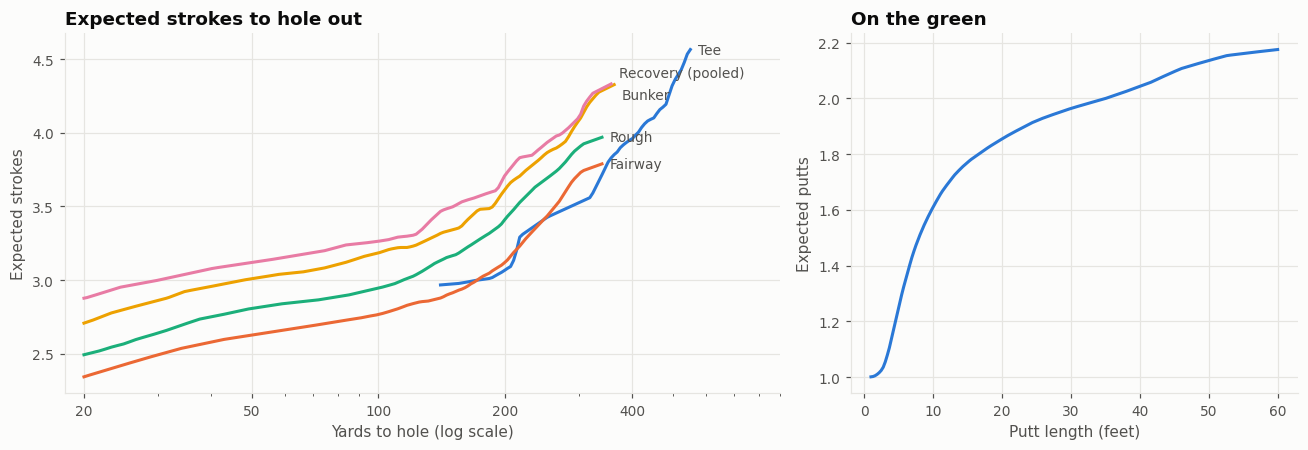

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
ax = axes[0]
show = [("LIE_16", "Tee"), ("LIE_4", "Fairway"), ("LIE_15", "Rough"), ("LIE_11", "Bunker"), ("recovery", "Recovery (pooled)")]
xs = np.geomspace(20, 550, 200)
for (code, name), col in zip(show, PALETTE):
    lo, hi = np.exp(base.grid[code][0][[0, -1]])
    x = xs[(xs >= max(lo, 20)) & (xs <= hi)]
    y = base.predict(pd.Series([code if code != "recovery" else "LIE_1"] * len(x)), pd.Series(x))
    ax.plot(x, y, color=col)
    nudge = {"Bunker": -7, "Recovery (pooled)": 7}.get(name, 0)
    ax.annotate(name, xy=(x[-1], y[-1]), xytext=(5, nudge), textcoords="offset points", va="center", fontsize=9, color=INK_2)
ax.set_xscale("log"); ax.set_xticks([20, 50, 100, 200, 400]); ax.set_xticklabels(["20", "50", "100", "200", "400"])
ax.set(title="Expected strokes to hole out", xlabel="Yards to hole (log scale)", ylabel="Expected strokes")
ax.set_xlim(18, 900)

ax = axes[1]
ft = np.linspace(1, 60, 200)
ax.plot(ft, base.predict(pd.Series(["LIE_6"] * len(ft)), pd.Series(ft / 3)), color=PALETTE[0])
ax.set(title="On the green", xlabel="Putt length (feet)", ylabel="Expected putts")
plt.tight_layout(); plt.show()

From 150 yards, the fairway is worth about 2.9 strokes and the rough about 3.2. A 10-foot putt is worth about 1.6. Driver distances average around 297 yards, which looks like a men's tour. Our ratings are relative to the field, so that does not change anything.

## Strokes Gained per shot

Strokes Gained = expected before − expected after − 1. A penalty counts against the shot that caused it. Per hole, the shots should add up exactly to expected-from-the-tee minus the score.

In [4]:
shots = add_strokes_gained(shots, base)
det = shots[~shots.score_only_hole]
per_hole = det.groupby(HOLE_KEY).agg(sg=("sg", "sum"), score=("hole_score", "first"), e_tee=("E_before", "first"))
print("Largest gap between sum(SG) and E(tee) − score:", (per_hole.e_tee - per_hole.score - per_hole.sg).abs().max())

Largest gap between sum(SG) and E(tee) − score: 1.7763568394002505e-15


They do (the error is zero). One example with a penalty:

In [5]:
k = det[det.is_penalty & det.category.eq("OTT")].iloc[3]
ex = shots.loc[(shots[HOLE_KEY] == k[HOLE_KEY]).all(axis=1),
               ["shot_no", "category", "lie_before", "yd_before", "lie_after", "yd_after", "is_penalty", "E_before", "E_after", "sg"]]
ex["lie_before"] = ex.lie_before.map(LIE_LABEL); ex["lie_after"] = ex.lie_after.map(LIE_LABEL)
print(f"Score {int(k.hole_score)} (par {int(k.par)}). E(tee) = {ex.E_before.iloc[0]:.2f}, total SG = {ex.sg.sum():+.2f}")
ex.round(2)

Score 5 (par 4). E(tee) = 4.07, total SG = -0.93


,shot_no,category,lie_before,yd_before,lie_after,yd_after,is_penalty,E_before,E_after,sg
2665,1,OTT,Tee,432.00,Water (penalty area),104.97,False,4.07,3.80,-0.73
2666,2,OTT,NaN,NaN,Fairway,110.60,True,NaN,2.80,0.00
2667,3,APP,Fairway,110.60,Green,8.54,False,2.80,1.93,-0.12
2668,4,PUTT,Green,8.54,Green,0.11,False,1.93,1.00,-0.07
2669,5,PUTT,Green,0.11,Holed,0.00,False,1.00,0.00,0.00


## From shots to rounds

For each round we add up each player's Strokes Gained and compare with the field that day. Total uses hole scores, so it includes the score-only holes. The four shot types use full-detail rounds only.

In [6]:
rounds = round_table(shots)
cols = ["sg_total"] + [f"sg_{c}" for c in CATEGORIES]
print(f"{len(rounds):,} player-rounds; {rounds.sg_OTT.notna().sum():,} with full shot detail")
summary = pd.DataFrame({"round-to-round SD": rounds[cols].std()})
summary

9,483 player-rounds; 9,390 with full shot detail


,round-to-round SD
sg_total,2.828558
sg_OTT,1.094917
sg_APP,1.624867
sg_ARG,1.171571
sg_PUTT,1.685072


In [7]:
rounds[cols].corr().round(2)

,sg_total,sg_OTT,sg_APP,sg_ARG,sg_PUTT
sg_total,1.00,0.40,0.58,0.41,0.57
sg_OTT,0.40,1.00,0.06,-0.01,-0.03
sg_APP,0.58,0.06,1.00,0.00,-0.02
sg_ARG,0.41,-0.01,0.00,1.00,-0.00
sg_PUTT,0.57,-0.03,-0.02,-0.00,1.00


One round swings by about ±2.8 strokes. The four shot types are almost unrelated within a round, so we can treat them as separate skills. 

## Skill, luck and field strength

Each round = skill + a term for how strong that field was + noise. The field term exists because top players enter tougher events. Players with few rounds are pulled toward average; the data decides how hard (empirical Bayes). Older rounds count less (12-month half-life).

In [8]:
ratings, fits = rate_all(rounds, detail_filter=~rounds.low_quality, half_life_days=365)
comp = pd.DataFrame({
    m.replace("sg_", ""): {
        "noise SD per round (σ_noise)": f.sigma_e,
        "true skill SD (σ_skill)": f.sigma_s,
        "λ (effective rounds)": f.lam,
        "share of edge kept at median sample": np.median(f.skills.n_eff) / (np.median(f.skills.n_eff) + f.lam),
    } for m, f in fits.items()
}).T
comp.round(2)

,noise SD per round (σ_noise),true skill SD (σ_skill),λ (effective rounds),share of edge kept at median sample
total,2.80,0.65,18.55,0.75
OTT,1.04,0.35,8.83,0.86
APP,1.65,0.25,44.28,0.55
ARG,1.16,0.17,45.25,0.54
PUTT,1.70,0.22,59.95,0.47


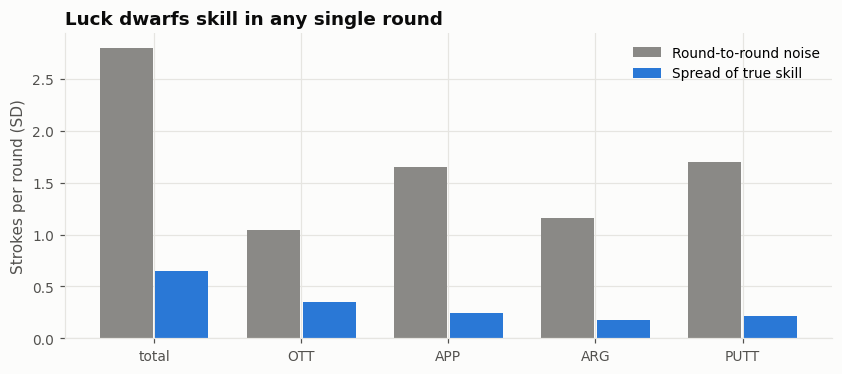

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6))
x = np.arange(len(comp)); wdt = 0.36
ax.bar(x - wdt / 2 - 0.01, comp["noise SD per round (σ_noise)"], wdt, color=NEUTRAL, label="Round-to-round noise")
ax.bar(x + wdt / 2 + 0.01, comp["true skill SD (σ_skill)"], wdt, color=PALETTE[0], label="Spread of true skill")
ax.set_xticks(x); ax.set_xticklabels(comp.index)
ax.set(title="Luck dwarfs skill in any single round", ylabel="Strokes per round (SD)")
ax.legend(loc="upper right")
plt.show()

This is the key chart. Luck in one round (±2.8) is about four times the skill gap between players (±0.65). Driving is the most repeatable skill, and putting the least.Then we will find how shrinkage treats small samples.

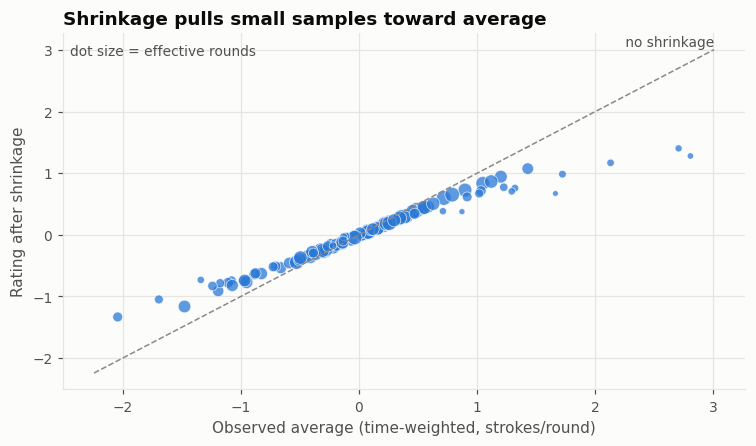

In [10]:
f = fits["sg_total"].skills
fig, ax = plt.subplots(figsize=(8, 4.2))
sc = ax.scatter(f.raw_mean, f.skill, s=np.clip(f.n_eff, 5, None) * 1.2, color=PALETTE[0], alpha=0.75, edgecolor="white", linewidth=0.5)
lim = [f.raw_mean.min() - 0.2, f.raw_mean.max() + 0.2]
ax.plot(lim, lim, color=NEUTRAL, lw=1, ls="--")
ax.text(lim[1], lim[1], " no shrinkage", fontsize=9, color=INK_2, va="bottom", ha="right")
ax.set(title="Shrinkage pulls small samples toward average", xlabel="Observed average (time-weighted, strokes/round)",
       ylabel="Rating after shrinkage")
ax.text(0.01, 0.97, "dot size = effective rounds", transform=ax.transAxes, fontsize=9, color=INK_2, va="top")
plt.show()

Players with few rounds (small dots) are pulled toward average. 

## Does it predict unseen rounds?
Test the ratings on rounds they have not seen.

Train on everything before a date, predict the next four months, and repeat at four dates. Compared with last season's seed and with a plain average.

In [11]:
def seed_prediction(train):
    t = train.groupby("player_id").agg(y=("sg_total", "mean"), seed=("seed", "first"))
    b = np.polyfit(np.log(t.seed), t.y, 1)
    return pd.Series(np.polyval(b, np.log(t.seed)), index=t.index)

grid = [dict(name="Model: empirical-Bayes λ, 12-month half-life", half_life_days=365),
        dict(name="Model without field-strength term", half_life_days=365, use_field=False),
        dict(name="Model without time decay", half_life_days=None),
        dict(name="Plain average (no shrinkage)", shrink=False, use_field=False, half_life_days=None)]
lam_grid = [dict(name=f"λ = {l}", lam_fixed=l, half_life_days=365) for l in [3, 6, 10, 15, 20, 25, 30, 40, 60]]
val, folds = evaluate_grid(rounds, "sg_total", grid + lam_grid, extra={"Seed only": seed_prediction})
val.loc[[g["name"] for g in grid] + ["Seed only"]].round(4)

,gain_per_round,rmse
model,,
"Model: empirical-Bayes λ, 12-month half-life",0.1040,2.7973
Model without field-strength term,0.1014,2.7977
Model without time decay,0.0953,2.7988
Plain average (no shrinkage),-0.1221,2.8374
Seed only,0.0398,2.8087


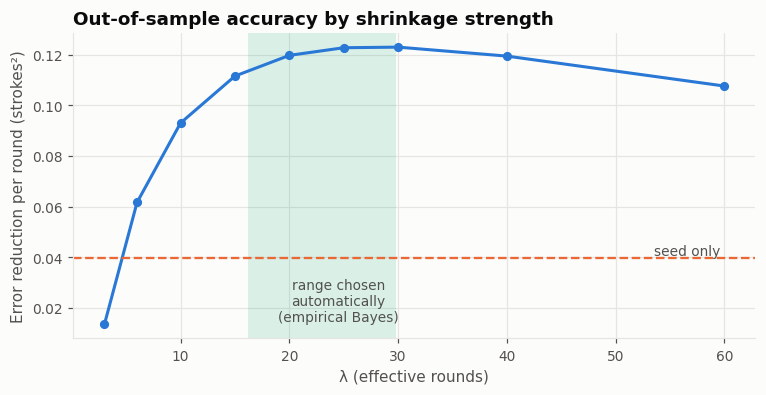

In [12]:
lam_curve = val.loc[[g["name"] for g in lam_grid], "gain_per_round"]
lam_x = [g["lam_fixed"] for g in lam_grid]
eb_lams = []
for c in pd.to_datetime(["2022-07-01", "2022-10-01", "2023-05-01", "2023-08-01"]):
    eb_lams.append(fit_ratings(rounds[rounds.date < c], "sg_total", ref_date=c, half_life_days=365).lam)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(lam_x, lam_curve.values, color=PALETTE[0], marker="o", ms=5)
ax.axvspan(min(eb_lams), max(eb_lams), color=PALETTE[2], alpha=0.15, lw=0)
ax.text(np.mean(eb_lams), lam_curve.min(), "range chosen\nautomatically\n(empirical Bayes)", ha="center", va="bottom", fontsize=9, color=INK_2)
ax.axhline(val.loc["Seed only", "gain_per_round"], color=PALETTE[1], lw=1.5, ls="--")
ax.text(lam_x[-1], val.loc["Seed only", "gain_per_round"], "seed only ", ha="right", va="bottom", fontsize=9, color=INK_2)
ax.set(title="Out-of-sample accuracy by shrinkage strength", xlabel="λ (effective rounds)", ylabel="Error reduction per round (strokes²)")
plt.show()

The model does about 2.5 times better than the seed. A plain average does worse than guessing everyone is average, because it chases noise. The shrinkage strength the data picked sits close to where accuracy peaks.

In [13]:
folds.pivot_table(index="model", columns="cutoff", values="gain").loc[[g["name"] for g in grid] + ["Seed only"]].round(3)

cutoff,2022-07-01,2022-10-01,2023-05-01,2023-08-01
model,,,,
"Model: empirical-Bayes λ, 12-month half-life",-0.043,0.096,0.215,0.245
Model without field-strength term,-0.031,0.095,0.201,0.229
Model without time decay,-0.083,0.071,0.230,0.279
Plain average (no shrinkage),-0.593,-0.056,0.213,0.274
Seed only,0.026,0.082,-0.021,0.062


The first fold has only six months of training data, so that's probs the reason every model struggles there. 

## Robustness

In [14]:
fa = fits["sg_total"].field_adj.rename("field_adj")
fa.index.names = ["event_id", "round_no", "course_no"]
rr = rounds.join(fa, on=["event_id", "round_no", "course_no"])
ev = rr.assign(top10=rr.seed <= 10).groupby("event_id").agg(field_adj=("field_adj", "mean"), top10_share=("top10", "mean"))
print(f"Correlation between an event's share of top-10 seeds and its field term: {ev.corr().iloc[0, 1]:.2f}")
rr.assign(top10=np.where(rr.seed <= 10, "seed 1-10", "seed 11+")).groupby("top10").field_adj.mean().round(3)

Correlation between an event's share of top-10 seeds and its field term: -0.79


top10
seed 1-10   -0.081
seed 11+     0.018
Name: field_adj, dtype: float64

Events with more top-10 seeds really are tougher, by about 0.1 strokes per round for a top player.
But, do the four rougher events matter?

In [15]:
sens = {}
for m in [f"sg_{c}" for c in CATEGORIES]:
    a = fit_ratings(rounds, m).skills.skill
    b = fit_ratings(rounds[~rounds.low_quality], m).skills.skill
    sens[m] = a.corr(b)
pd.Series(sens, name="correlation of ratings").round(3)

sg_OTT     0.996
sg_APP     0.990
sg_ARG     0.989
sg_PUTT    0.985
Name: correlation of ratings, dtype: float64

They barely change the ratings (r ≥ 0.98).

## The ratings

In [16]:
ratings = ratings.join(rounds.groupby("player_id").seed.first()).join(style_profile(shots))
ratings["rank"] = ratings.total.rank(ascending=False).astype(int)
show_cols = ["rank", "seed", "total", "total_sd", "OTT", "APP", "ARG", "PUTT", "n_rounds"]
ratings.sort_values("total", ascending=False)[show_cols].head(25).round(2)

,rank,seed,total,total_sd,OTT,APP,ARG,PUTT,n_rounds
player_id,,,,,,,,,
038e1fbfb9,1,1,1.40,0.47,0.72,0.23,0.04,0.14,32
e9f3aa5351,2,2,1.28,0.49,0.86,0.13,0.12,0.10,23
3f050f6437,3,6,1.17,0.46,0.43,0.03,0.17,0.12,32
8399e3fca3,4,34,1.07,0.35,0.26,0.21,0.12,0.14,91
43b0b619fe,5,8,0.98,0.45,0.28,0.26,0.06,0.07,40
4a245c5a52,6,57,0.94,0.33,0.52,0.16,0.01,0.24,105
9970383dd6,7,42,0.87,0.31,-0.27,0.23,0.15,0.41,113
3026b3a2ae,8,36,0.84,0.31,0.69,0.23,0.05,-0.02,116
bfac4fb27e,9,3,0.77,0.43,0.43,0.37,0.06,-0.09,48


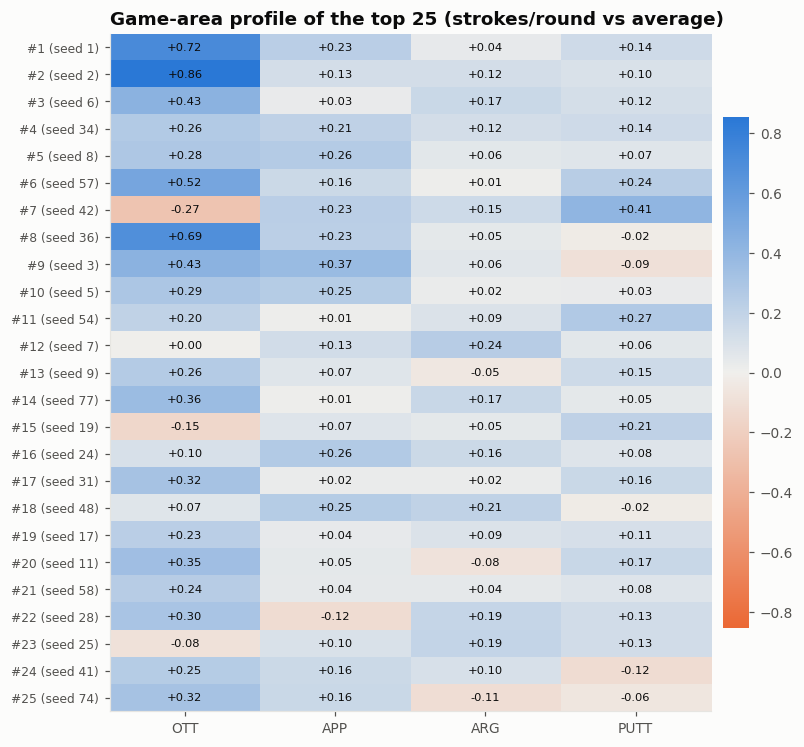

In [17]:
top = ratings.sort_values("total", ascending=False).head(25)
mat = top[CATEGORIES].to_numpy()
fig, ax = plt.subplots(figsize=(7.5, 8))
vmax = np.abs(mat).max()
im = ax.imshow(mat, cmap=DIVERGING, vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(4)); ax.set_xticklabels(CATEGORIES)
ax.set_yticks(range(len(top))); ax.set_yticklabels([f"#{r} (seed {s})" for r, s in zip(top["rank"], top.seed)], fontsize=8)
for i in range(mat.shape[0]):
    for j in range(4):
        ax.text(j, i, f"{mat[i, j]:+.2f}", ha="center", va="center", fontsize=7.5, color="#0b0b0b")
ax.grid(False)
ax.set_title("Game-area profile of the top 25 (strokes/round vs average)")
cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02); cb.outline.set_visible(False)
plt.show()

Good players get there in different ways: some drive it far, some hit great approaches. Notebook 04 checks whether mixing styles helps a pair.

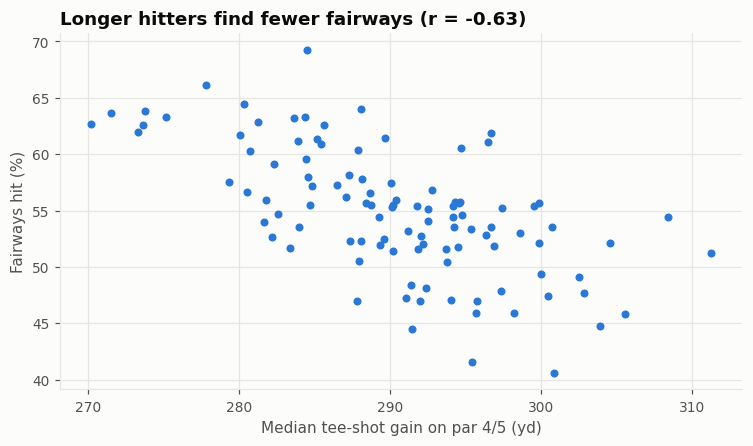

,OTT,drive_yd,fairway_pct,ott_penalty
OTT,1.00,0.55,0.22,-0.45
drive_yd,0.55,1.00,-0.63,0.35
fairway_pct,0.22,-0.63,1.00,-0.76
ott_penalty,-0.45,0.35,-0.76,1.00


In [18]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.scatter(ratings.drive_yd, ratings.fairway_pct * 100, s=18, color=PALETTE[0])
r_ = ratings[["drive_yd", "fairway_pct"]].corr().iloc[0, 1]
ax.set(title=f"Longer hitters find fewer fairways (r = {r_:.2f})", xlabel="Median tee-shot gain on par 4/5 (yd)", ylabel="Fairways hit (%)")
plt.show()
ratings[["OTT", "drive_yd", "fairway_pct", "ott_penalty"]].corr().round(2)

Longer hitters find fewer fairways, but distance matters more than accuracy for driving value.

## Where the seed gets it wrong

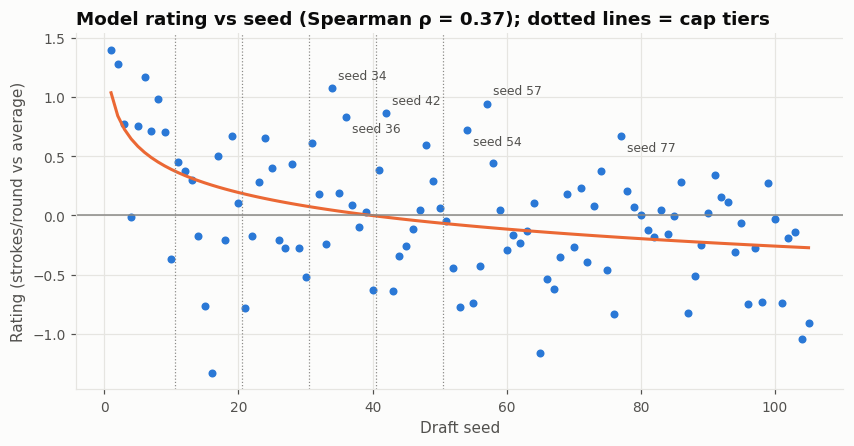

In [19]:
rho = spearmanr(ratings.seed, -ratings.total).statistic
b = np.polyfit(np.log(ratings.seed), ratings.total, 1)
ratings["expected_from_seed"] = np.polyval(b, np.log(ratings.seed))
ratings["value_over_seed"] = ratings.total - ratings.expected_from_seed
ratings["tier"] = pd.cut(ratings.seed, [0, 10, 20, 30, 40, 50, 200], labels=["1-10", "11-20", "21-30", "31-40", "41-50", "51+"])

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.scatter(ratings.seed, ratings.total, s=18, color=PALETTE[0])
xs = np.arange(1, 106)
ax.plot(xs, np.polyval(b, np.log(xs)), color=PALETTE[1], lw=2)
for t in [10.5, 20.5, 30.5, 40.5, 50.5]:
    ax.axvline(t, color=NEUTRAL, lw=0.8, ls=":")
best = ratings.sort_values("value_over_seed", ascending=False).head(6)
for j, (pid, row) in enumerate(best.sort_values("seed").iterrows()):
    ax.annotate(f"seed {row.seed}", (row.seed, row.total), xytext=(4, 6 if j % 2 == 0 else -10),
                textcoords="offset points", fontsize=8, color=INK_2)
ax.axhline(0, color=NEUTRAL, lw=1)
ax.set(title=f"Model rating vs seed (Spearman ρ = {rho:.2f}); dotted lines = cap tiers",
       xlabel="Draft seed", ylabel="Rating (strokes/round vs average)")
plt.show()

In [20]:
ratings.sort_values("value_over_seed", ascending=False).groupby("tier", observed=True).head(3).sort_values(
    ["tier", "value_over_seed"], ascending=[True, False])[["tier", "seed", "rank", "total", "expected_from_seed", "value_over_seed", "OTT", "APP", "ARG", "PUTT"]].round(2)

,tier,seed,rank,total,expected_from_seed,value_over_seed,OTT,APP,ARG,PUTT
player_id,,,,,,,,,,
3f050f6437,1-10,6,3,1.17,0.53,0.64,0.43,0.03,0.17,0.12
43b0b619fe,1-10,8,5,0.98,0.45,0.53,0.28,0.26,0.06,0.07
e9f3aa5351,1-10,2,2,1.28,0.84,0.44,0.86,0.13,0.12,0.10
2a6f328407,11-20,19,15,0.67,0.21,0.46,-0.15,0.07,0.05,0.21
c300f4eee9,11-20,17,19,0.50,0.24,0.27,0.23,0.04,0.09,0.11
32be2f234f,11-20,11,20,0.46,0.36,0.09,0.35,0.05,-0.08,0.17
3beacf72a5,21-30,24,16,0.65,0.14,0.51,0.10,0.26,0.16,0.08
9bc33df2a4,21-30,28,22,0.44,0.10,0.34,0.30,-0.12,0.19,0.13
0b4a5e3f64,21-30,25,23,0.40,0.13,0.27,-0.08,0.10,0.19,0.13


The top-10 seeds are the strongest group, but every tier hides players who rate far above their seed. Those are the draft targets. Then we shall use a simulator to turn ratings into match results.

In [21]:
from src.pipeline import build
P = build(refresh=True)
print("Cached pipeline and wrote data/processed/player_ratings.csv:", P["ratings"].shape)

Cached pipeline and wrote data/processed/player_ratings.csv: (105, 18)
